<a href="https://www.kaggle.com/code/lalit7881/online-food-ordering-eda-94-87?scriptVersionId=346665709" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/online-food-ordering-dataset/online food delivery dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/srisyra02/online-food-ordering-dataset/online food delivery dataset.csv")

In [3]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [4]:
df.tail()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
387,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.8988,77.5764,560078,Yes,Positive,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

In [6]:
df.describe()

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [7]:
df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(103)

In [9]:
df.dtypes

Age                             int64
Gender                         object
Marital Status                 object
Occupation                     object
Monthly Income                 object
Educational Qualifications     object
Family size                     int64
Customer Type                  object
latitude                      float64
longitude                     float64
Pin code                        int64
Output                         object
Feedback                       object
Unnamed: 13                    object
dtype: object

In [10]:
df.shape

(388, 14)

In [11]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback',
       'Unnamed: 13'],
      dtype='object')

In [12]:
df.nunique()

Age                           16
Gender                         2
Marital Status                 3
Occupation                     4
Monthly Income                 5
Educational Qualifications     5
Family size                    6
Customer Type                  3
latitude                      77
longitude                     76
Pin code                      77
Output                         2
Feedback                       2
Unnamed: 13                    2
dtype: int64

## Feature engineering


After removing Unnamed: 13:
(388, 13)

MISSING VALUES
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
dtype: int64

Missing values after treatment:
0

TARGET VARIABLE - OUTPUT
Output
Yes    301
No      87
Name: count, dtype: int64

Unique Output Values:
['Yes' 'No']

Feature shape: (388, 12)
Target shape: (388,)

LABEL ENCODING
Target classes:
['No' 'Yes']

Encoded target:
[0 1]
Gender encoded -> 2 categories
Marital Status encoded -> 3 categories
Occupation encoded -> 4 categories
Monthly Income encoded -> 5 categories
Educational Qualifications encoded -> 5 categories
Customer Type encoded -> 3 categories
Feedback encoded

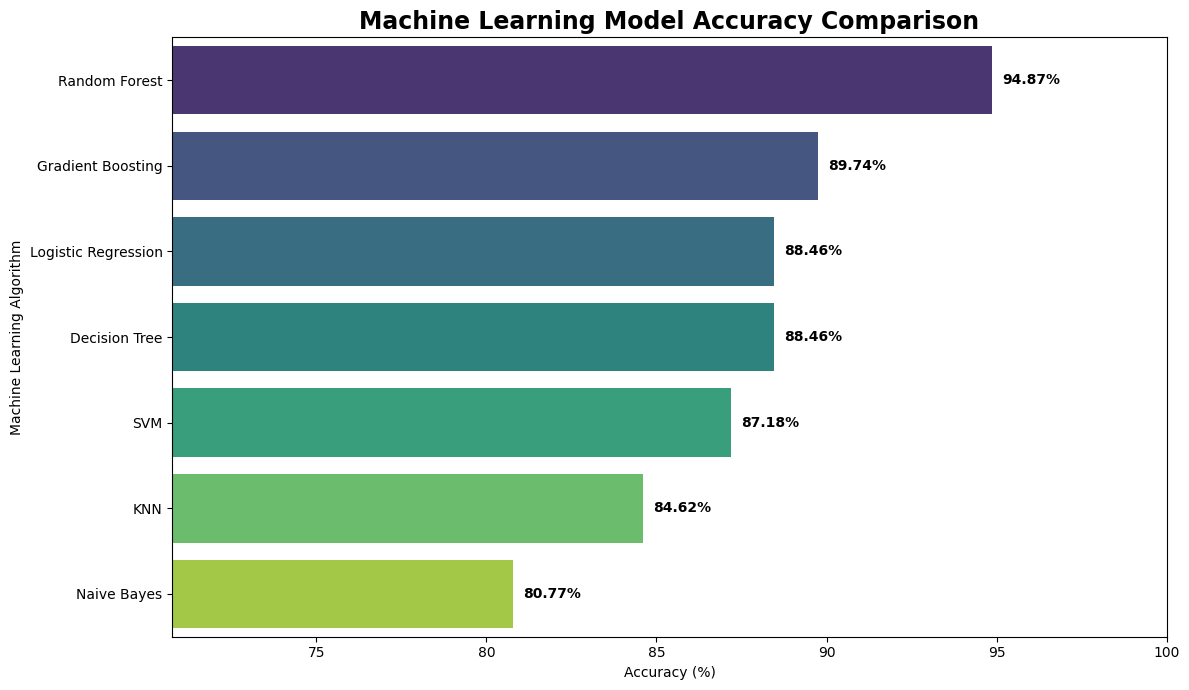

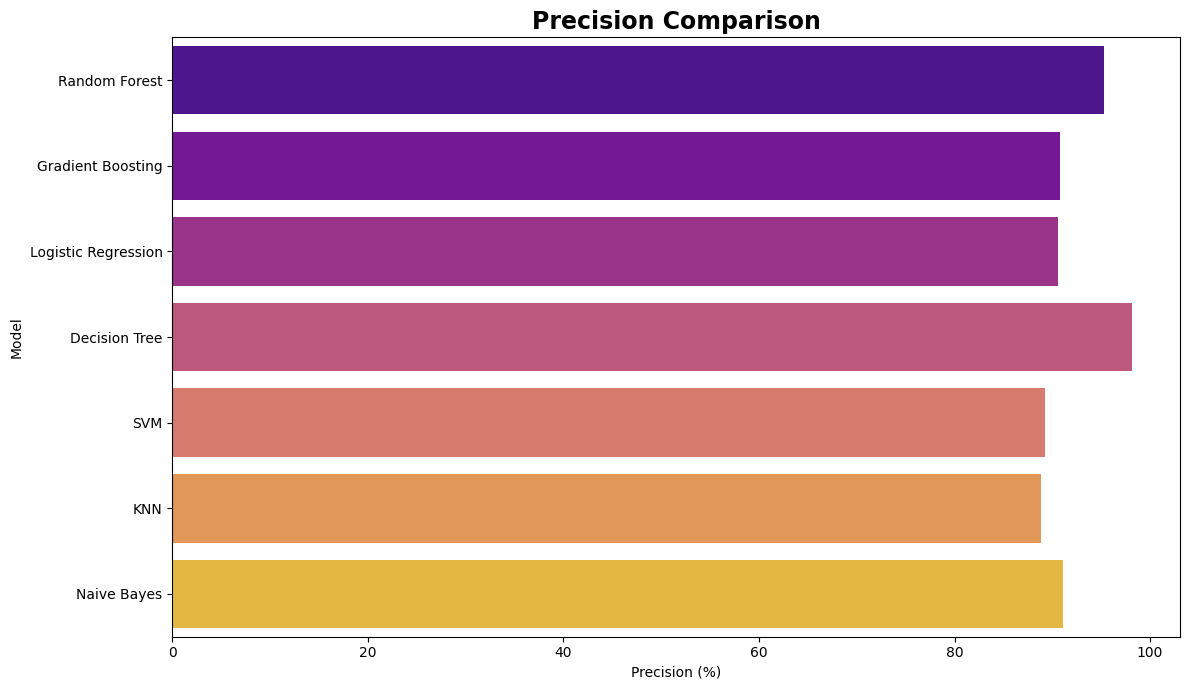

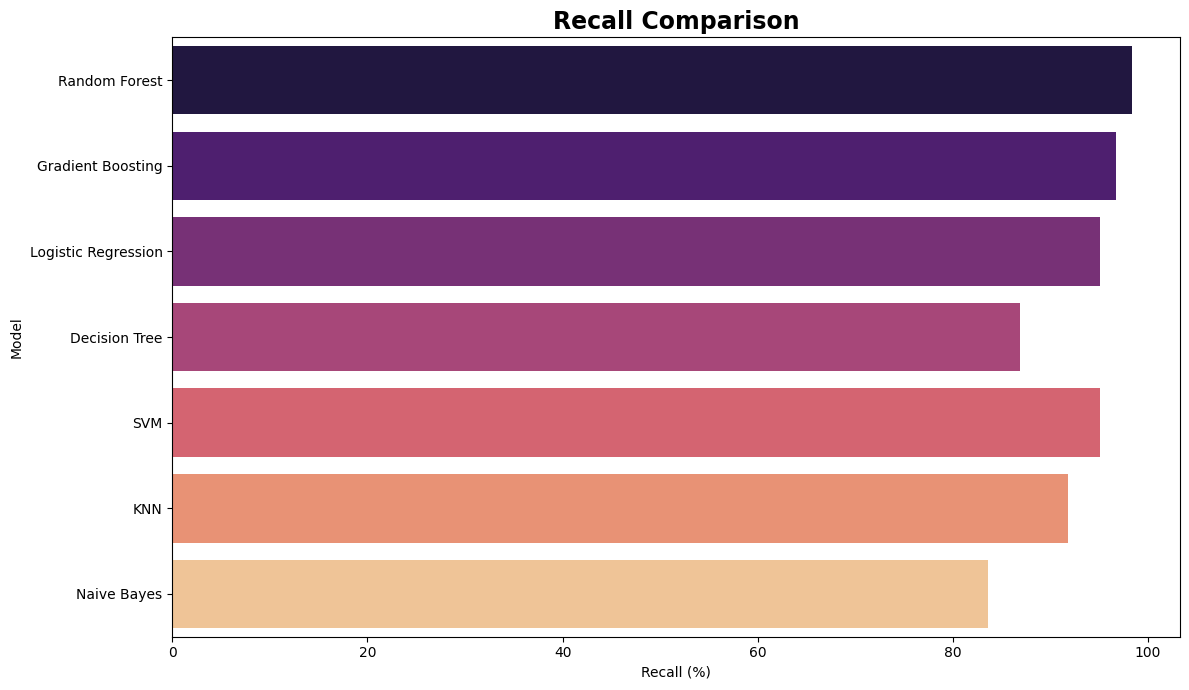

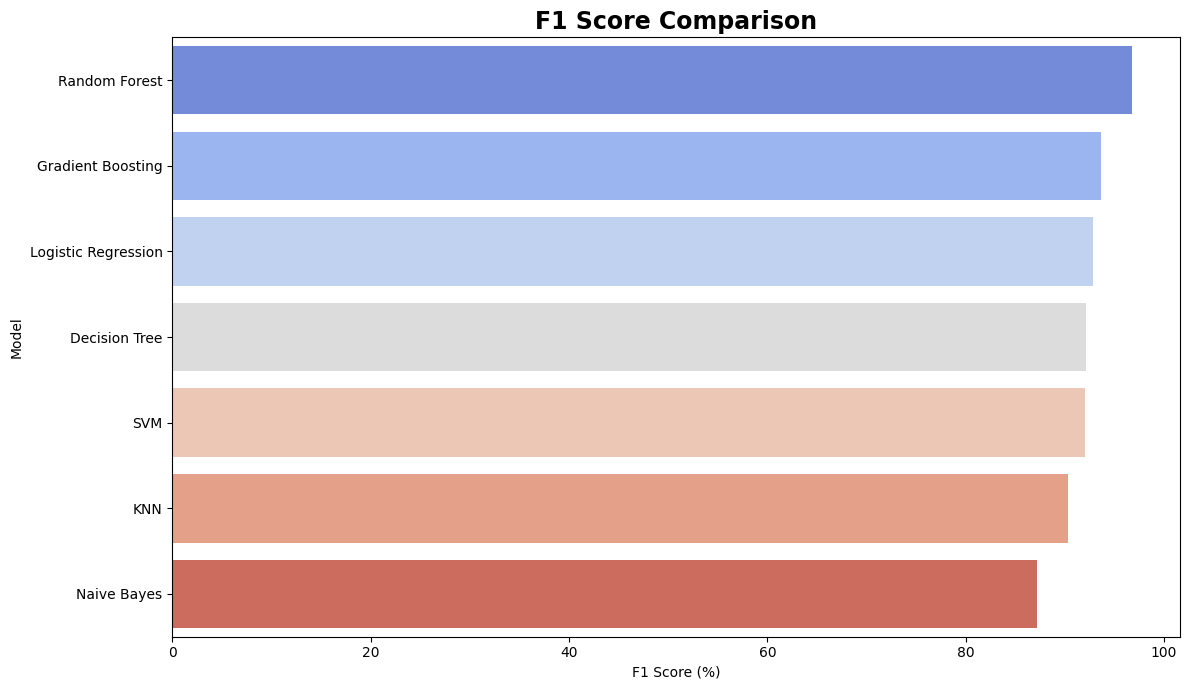

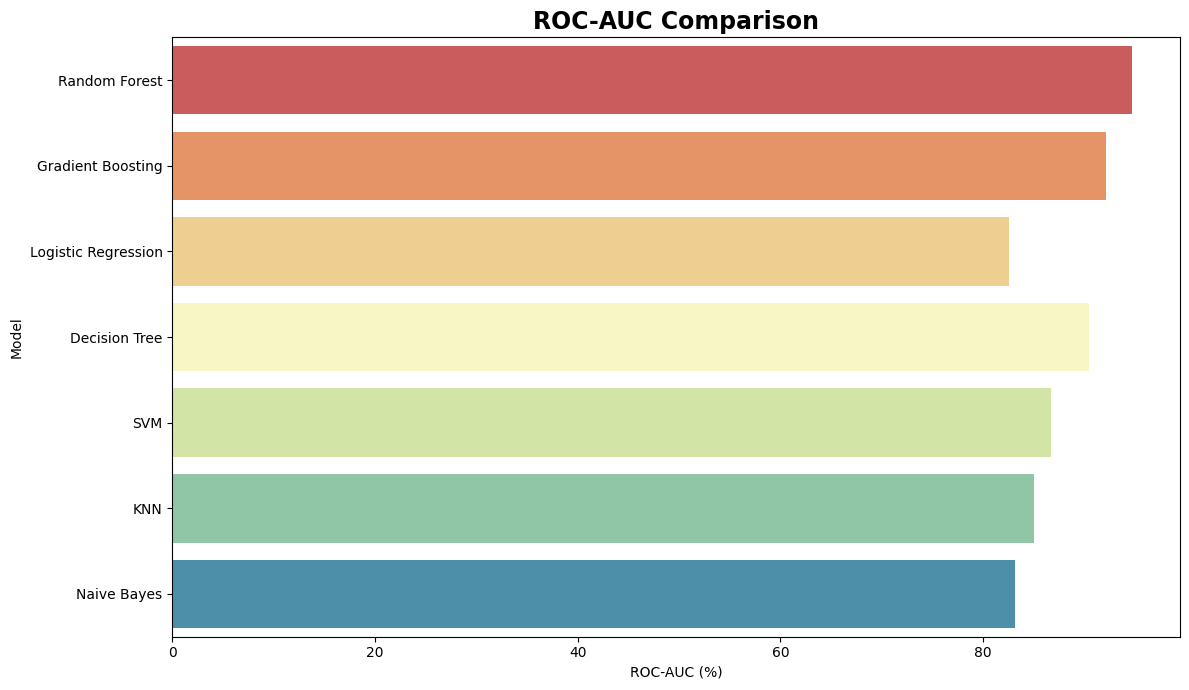

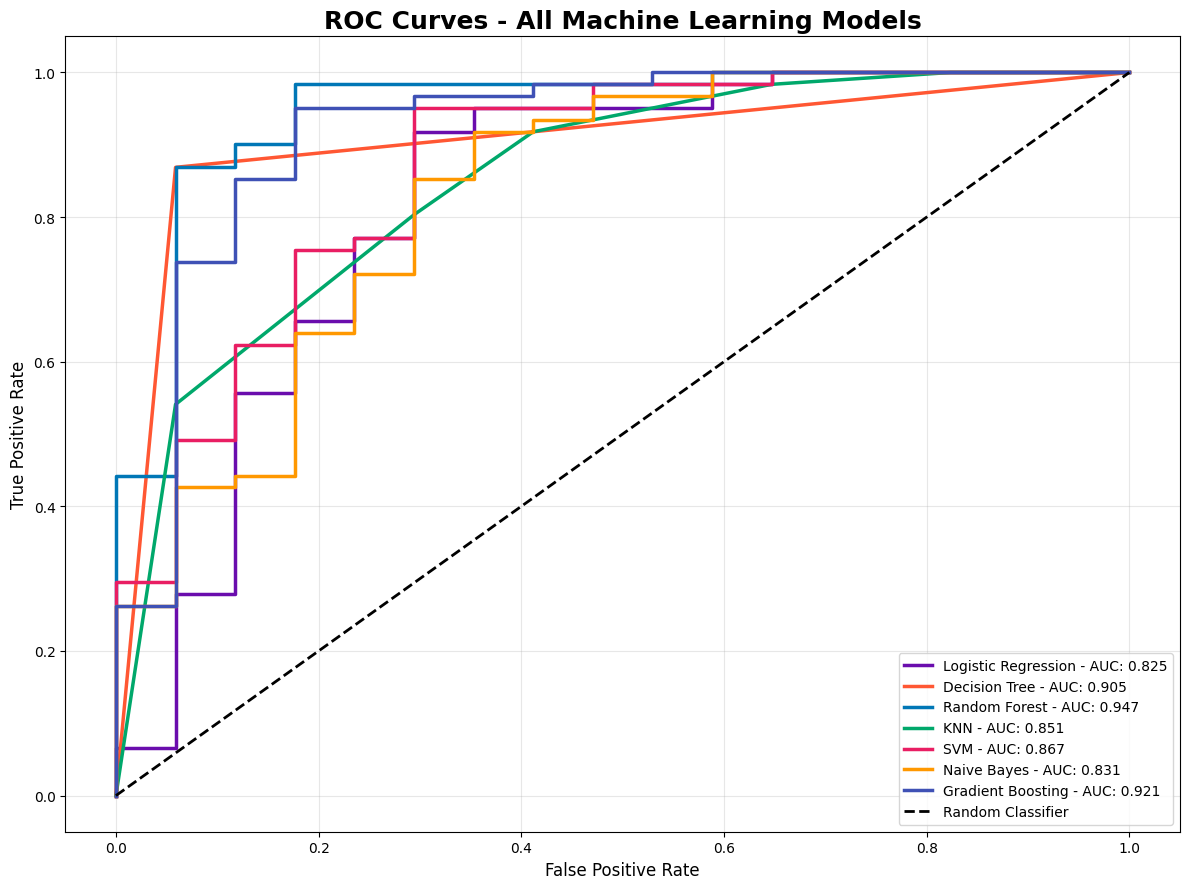

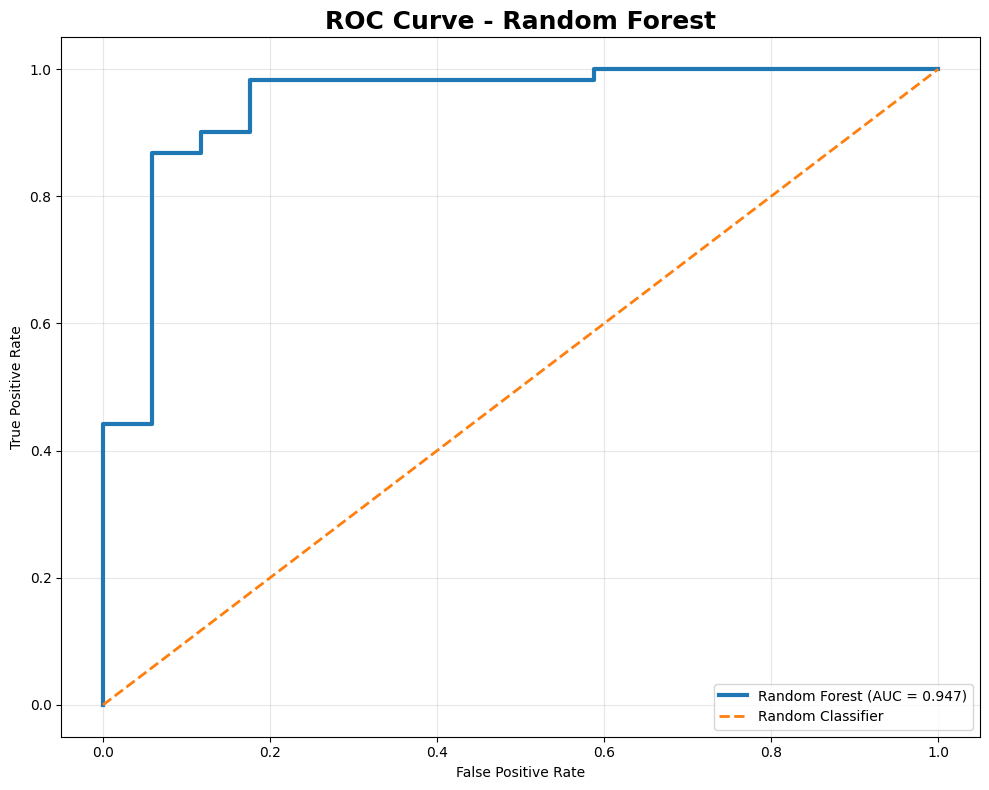

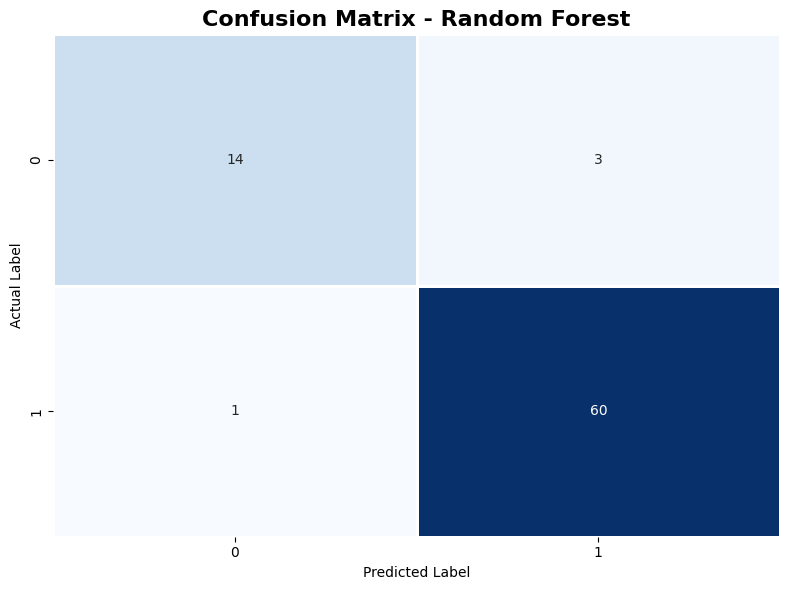


CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.93      0.82      0.88        17
         Yes       0.95      0.98      0.97        61

    accuracy                           0.95        78
   macro avg       0.94      0.90      0.92        78
weighted avg       0.95      0.95      0.95        78


BEST MODEL FINAL PERFORMANCE
Model       : Random Forest
Accuracy    : 94.87%
Precision   : 95.24%
Recall      : 98.36%
F1 Score    : 96.77%
ROC-AUC     : 94.70%

FEATURE IMPORTANCE
                       Feature  Importance
11                    Feedback    0.237755
8                     latitude    0.133063
9                    longitude    0.120776
0                          Age    0.113679
10                    Pin code    0.106824
6                  Family size    0.056688
4               Monthly Income    0.054638
5   Educational Qualifications    0.049785
3                   Occupation    0.043215
2               Marital Status    0.0

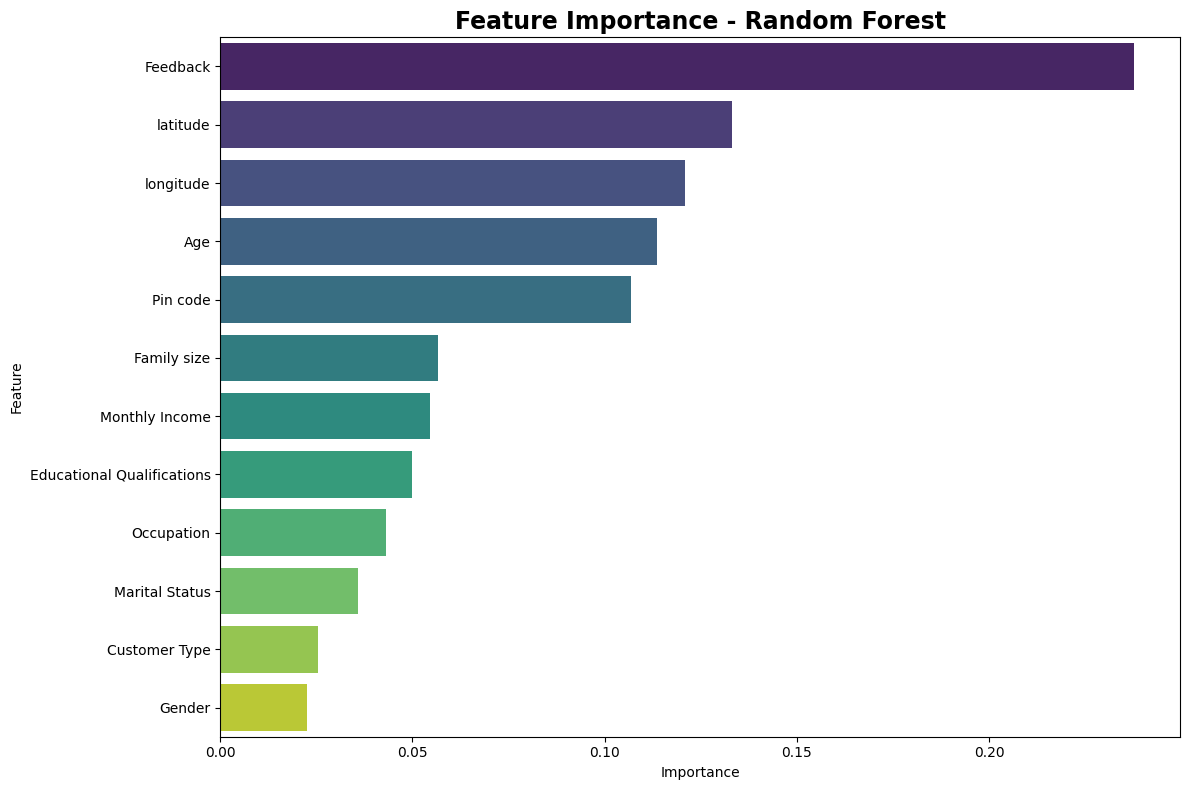


Model comparison saved as 'model_comparison_results.csv'


FINAL SUMMARY
Best Algorithm : Random Forest
Accuracy       : 94.87%
Precision      : 95.24%
Recall         : 98.36%
F1 Score       : 96.77%
ROC-AUC        : 94.70%
MACHINE LEARNING PIPELINE COMPLETED


In [13]:
# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier



if "Unnamed: 13" in df.columns:
    df.drop("Unnamed: 13", axis=1, inplace=True)

print("\nAfter removing Unnamed: 13:")
print(df.shape)


# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)

print(df.isnull().sum())


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

# Numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())


# Categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


print("\nMissing values after treatment:")
print(df.isnull().sum().sum())


# ============================================================
# 6. DISPLAY TARGET VARIABLE
# ============================================================

print("\n" + "=" * 80)
print("TARGET VARIABLE - OUTPUT")
print("=" * 80)

print(df["Output"].value_counts())

print("\nUnique Output Values:")
print(df["Output"].unique())


# ============================================================
# 7. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("Output", axis=1)

y = df["Output"]


print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 8. LABEL ENCODING
# ============================================================

print("\n" + "=" * 80)
print("LABEL ENCODING")
print("=" * 80)


# Encode target variable
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y.astype(str))


print("Target classes:")
print(target_encoder.classes_)

print("\nEncoded target:")
print(np.unique(y))


# ============================================================
# 9. LABEL ENCODE CATEGORICAL FEATURES
# ============================================================

feature_encoders = {}

for col in X.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(X[col].astype(str))

    feature_encoders[col] = encoder

    print(
        f"{col} encoded -> "
        f"{len(encoder.classes_)} categories"
    )


# ============================================================
# 10. CONVERT ALL FEATURES TO NUMERIC
# ============================================================

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(0)


print("\nFeature data types:")
print(X.dtypes)


# ============================================================
# 11. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print(
    "Training percentage:",
    round(len(X_train) / len(X) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(len(X_test) / len(X) * 100, 2),
    "%"
)


# ============================================================
# 12. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("\nFeature scaling completed.")


# ============================================================
# 13. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42,
            max_depth=10
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB(),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        )
}


# ============================================================
# 14. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}

probabilities = {}


print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)


for name, model in models.items():

    print(f"\nTraining: {name}")

    # Train
    model.fit(
        X_train_scaled,
        y_train
    )

    # Prediction
    y_pred = model.predict(
        X_test_scaled
    )

    # Probability
    y_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # Store
    results.append({
        "Model": name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100,
        "ROC-AUC (%)": roc_auc * 100
    })

    trained_models[name] = model

    predictions[name] = y_pred

    probabilities[name] = y_prob


# ============================================================
# 15. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy (%)": "{:.2f}".format,
            "Precision (%)": "{:.2f}".format,
            "Recall (%)": "{:.2f}".format,
            "F1 Score (%)": "{:.2f}".format,
            "ROC-AUC (%)": "{:.2f}".format
        }
    )
)


# ============================================================
# 16. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy (%)"]

best_model = trained_models[
    best_model_name
]


print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print("Model:", best_model_name)

print(
    "Accuracy:",
    round(best_accuracy, 2),
    "%"
)


# ============================================================
# 17. BAR CHART - ACCURACY
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Accuracy (%)",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Algorithm")

plt.xlim(
    max(0, results_df["Accuracy (%)"].min() - 10),
    100
)

# Add percentage labels

for i, value in enumerate(
    results_df["Accuracy (%)"]
):

    plt.text(
        value + 0.3,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 18. PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Precision (%)",
    y="Model",
    hue="Model",
    palette="plasma",
    legend=False
)

plt.title(
    "Precision Comparison",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Precision (%)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 19. RECALL COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Recall (%)",
    y="Model",
    hue="Model",
    palette="magma",
    legend=False
)

plt.title(
    "Recall Comparison",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Recall (%)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 20. F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="F1 Score (%)",
    y="Model",
    hue="Model",
    palette="coolwarm",
    legend=False
)

plt.title(
    "F1 Score Comparison",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("F1 Score (%)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 21. ROC-AUC COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="ROC-AUC (%)",
    y="Model",
    hue="Model",
    palette="Spectral",
    legend=False
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("ROC-AUC (%)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 22. ROC CURVES FOR ALL MODELS
# ============================================================

plt.figure(figsize=(12, 9))

colors = [
    "#6A0DAD",
    "#FF5733",
    "#0077B6",
    "#00A86B",
    "#E91E63",
    "#FF9800",
    "#3F51B5"
]


for (name, y_prob), color in zip(
    probabilities.items(),
    colors
):

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        color=color,
        label=f"{name} - AUC: {auc_score:.3f}"
    )


# Random classifier line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)


plt.title(
    "ROC Curves - All Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. BEST MODEL ROC CURVE
# ============================================================

best_probabilities = probabilities[
    best_model_name
]

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_probabilities
)

best_auc = roc_auc_score(
    y_test,
    best_probabilities
)


plt.figure(figsize=(10, 8))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"{best_model_name} (AUC = {best_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    f"ROC Curve - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. CONFUSION MATRIX - BEST MODEL
# ============================================================

best_predictions = predictions[
    best_model_name
]

cm = confusion_matrix(
    y_test,
    best_predictions
)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    cbar=False
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()


# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            str(x)
            for x in target_encoder.classes_
        ],
        zero_division=0
    )
)


# ============================================================
# 26. DETAILED BEST MODEL METRICS
# ============================================================

best_accuracy = accuracy_score(
    y_test,
    best_predictions
)

best_precision = precision_score(
    y_test,
    best_predictions,
    zero_division=0
)

best_recall = recall_score(
    y_test,
    best_predictions,
    zero_division=0
)

best_f1 = f1_score(
    y_test,
    best_predictions,
    zero_division=0
)

best_auc = roc_auc_score(
    y_test,
    best_probabilities
)


print("\n" + "=" * 80)
print("BEST MODEL FINAL PERFORMANCE")
print("=" * 80)

print(
    f"Model       : {best_model_name}"
)

print(
    f"Accuracy    : {best_accuracy * 100:.2f}%"
)

print(
    f"Precision   : {best_precision * 100:.2f}%"
)

print(
    f"Recall      : {best_recall * 100:.2f}%"
)

print(
    f"F1 Score    : {best_f1 * 100:.2f}%"
)

print(
    f"ROC-AUC     : {best_auc * 100:.2f}%"
)


# ============================================================
# 27. FEATURE IMPORTANCE
# ============================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n" + "=" * 80)
    print("FEATURE IMPORTANCE")
    print("=" * 80)

    print(importance)


    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="viridis",
        legend=False
    )

    plt.title(
        f"Feature Importance - {best_model_name}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()

    plt.show()


# ============================================================
# 28. SAVE MODEL COMPARISON
# ============================================================

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print(
    "\nModel comparison saved as "
    "'model_comparison_results.csv'"
)


# ============================================================
# 29. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(
    f"Best Algorithm : {best_model_name}"
)

print(
    f"Accuracy       : {best_accuracy * 100:.2f}%"
)

print(
    f"Precision      : {best_precision * 100:.2f}%"
)

print(
    f"Recall         : {best_recall * 100:.2f}%"
)

print(
    f"F1 Score       : {best_f1 * 100:.2f}%"
)

print(
    f"ROC-AUC        : {best_auc * 100:.2f}%"
)

print("=" * 80)
print("MACHINE LEARNING PIPELINE COMPLETED")
print("=" * 80)


After removing unwanted columns:
['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Family size', 'Customer Type', 'latitude', 'longitude', 'Pin code', 'Output', 'Feedback']

Duplicate rows removed: 103

CLEAN DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         285 non-null    int64  
 1   Gender                      285 non-null    object 
 2   Marital Status              285 non-null    object 
 3   Occupation                  285 non-null    object 
 4   Monthly Income              0 non-null      float64
 5   Educational Qualifications  285 non-null    object 
 6   Family size                 285 non-null    int64  
 7   Customer Type               285 non-null    object 
 8   latitude                    285 non-null 

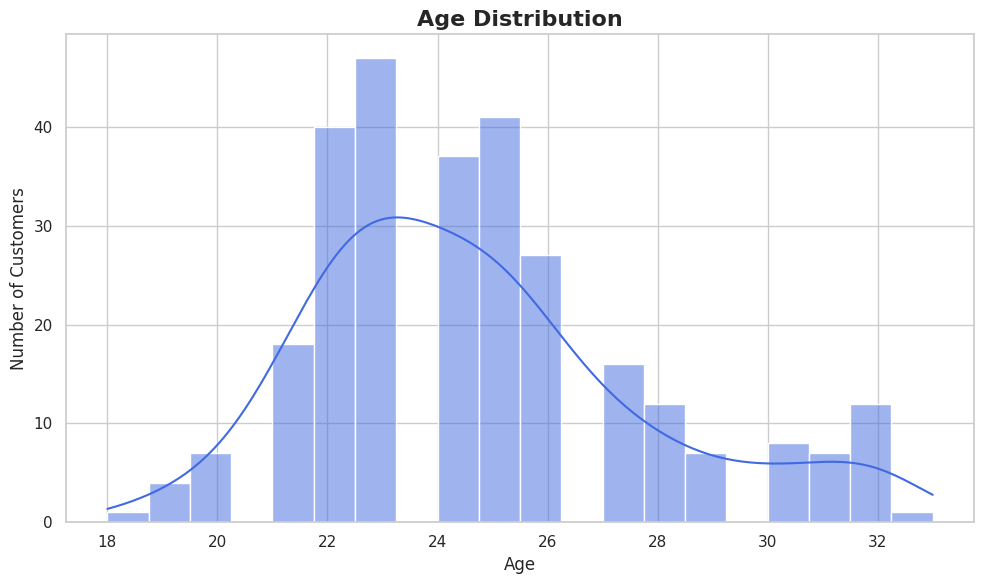

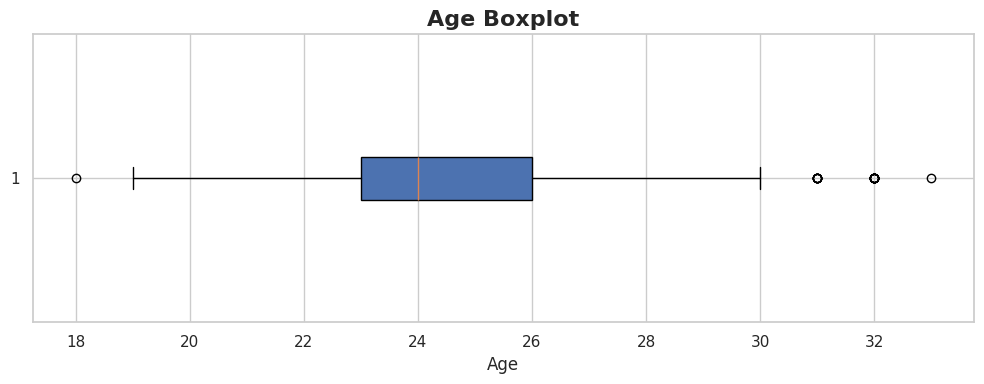

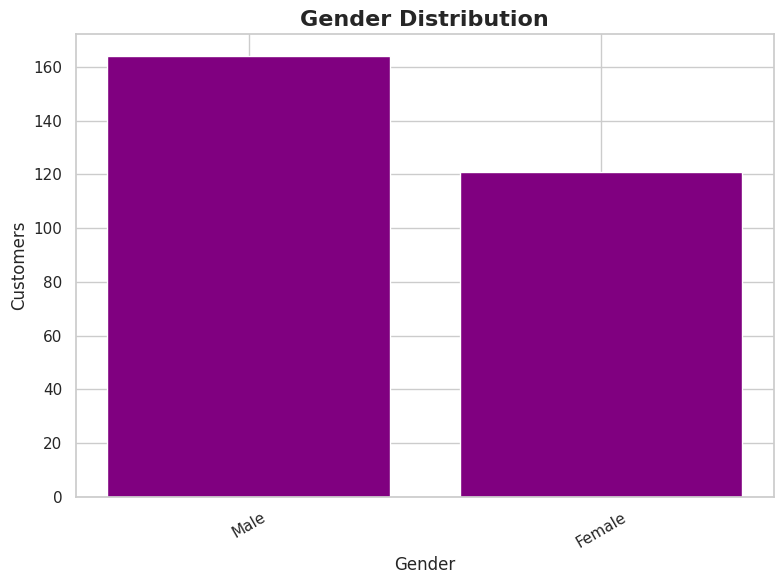

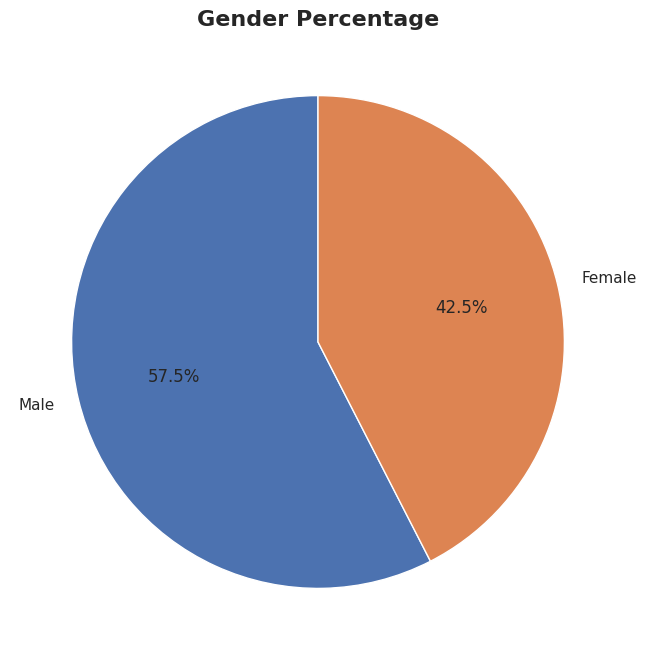

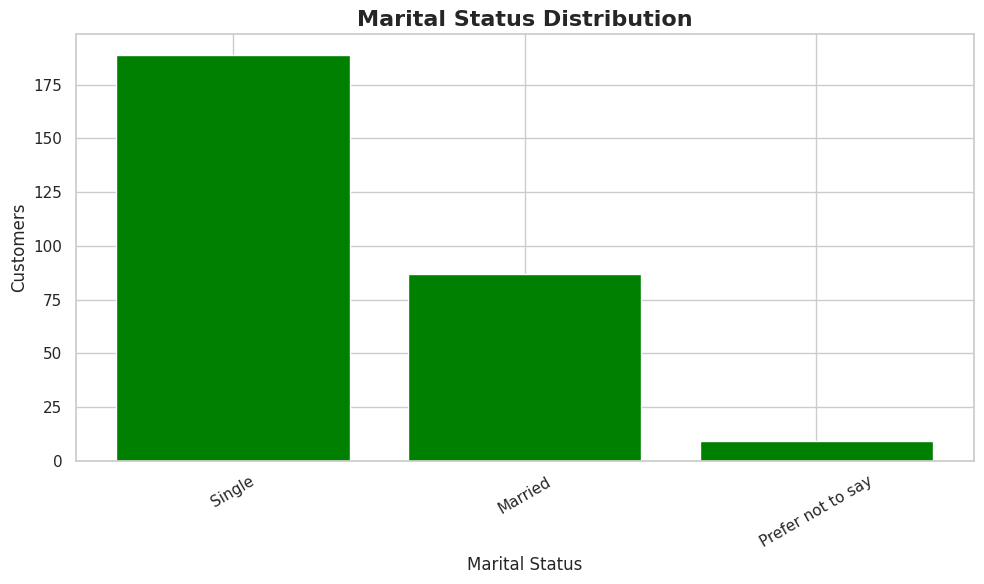

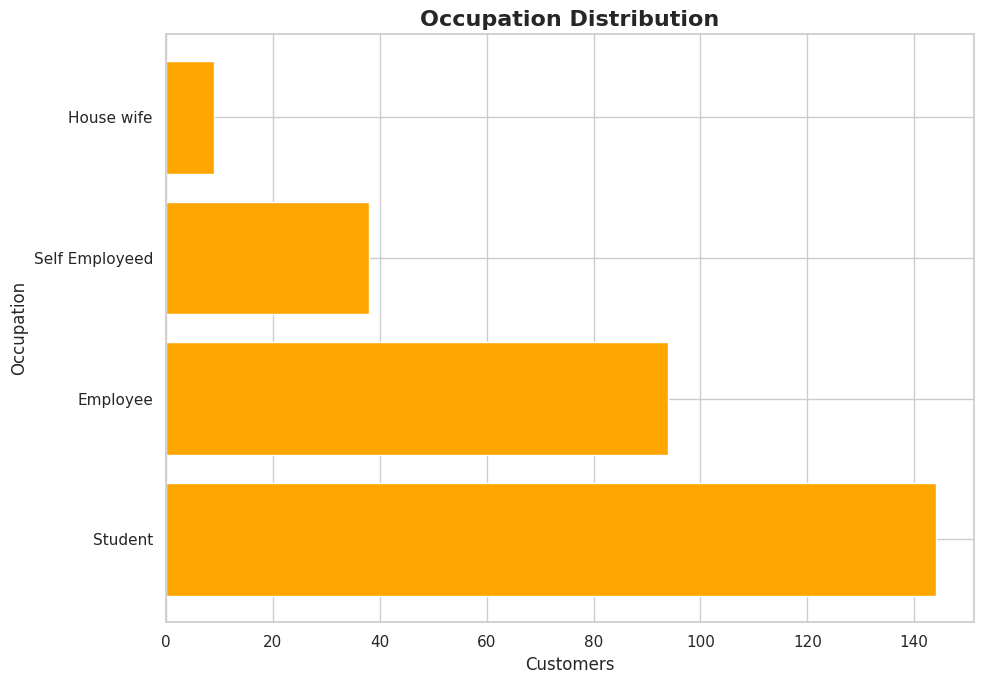


Monthly Income Statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Monthly Income, dtype: float64


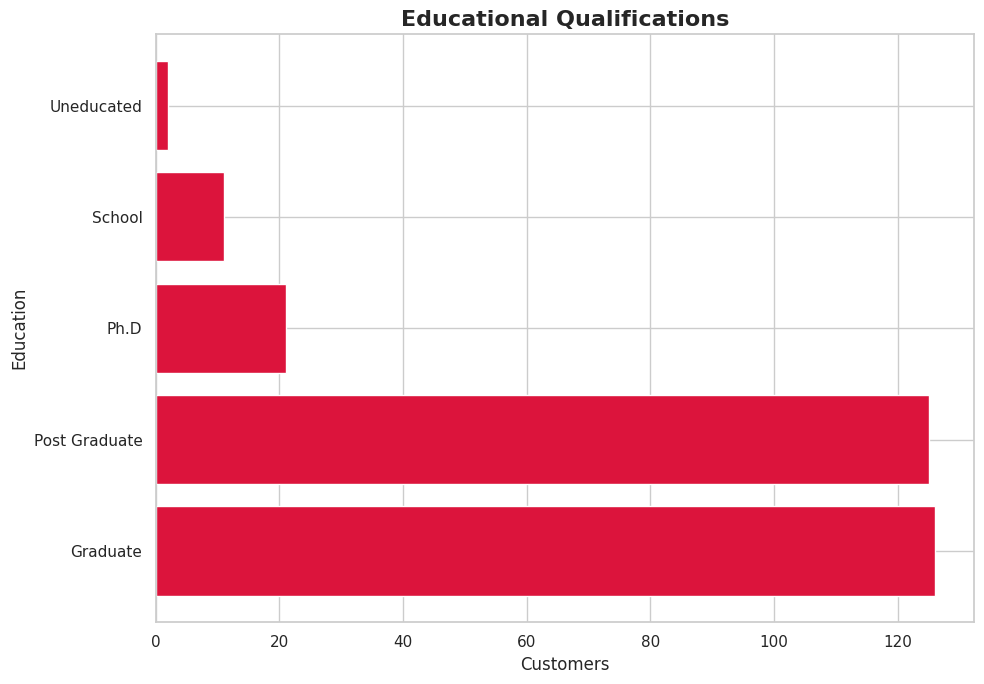

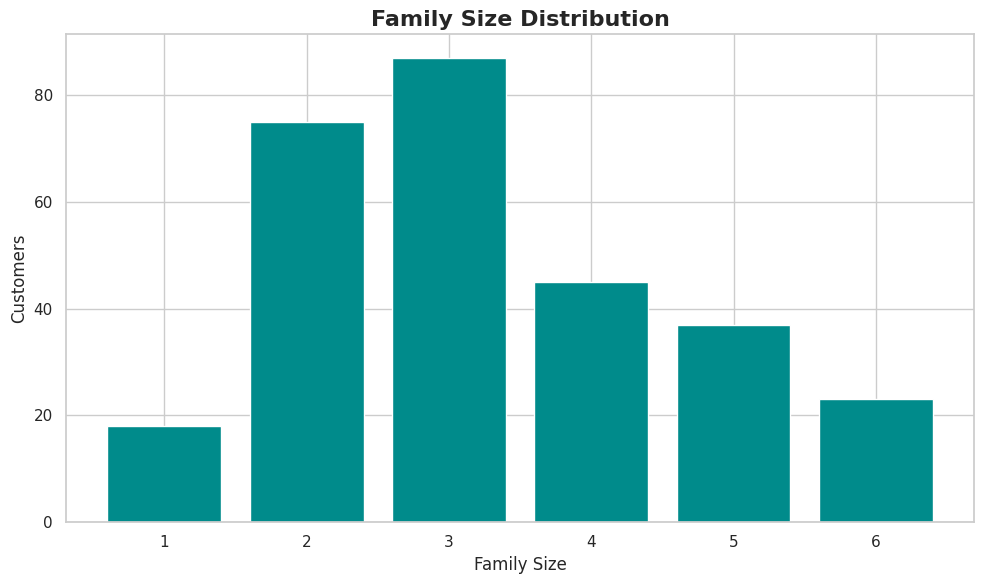

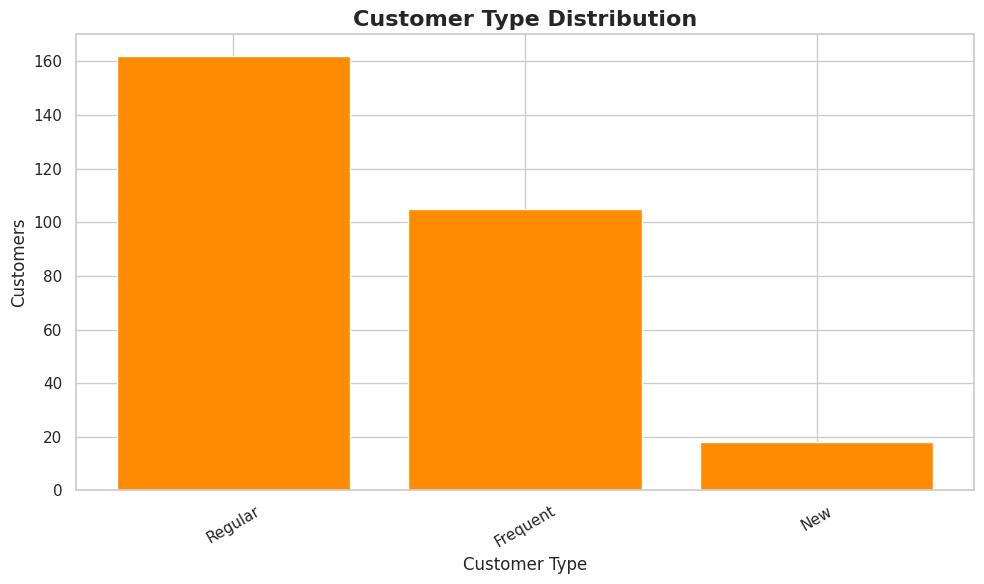

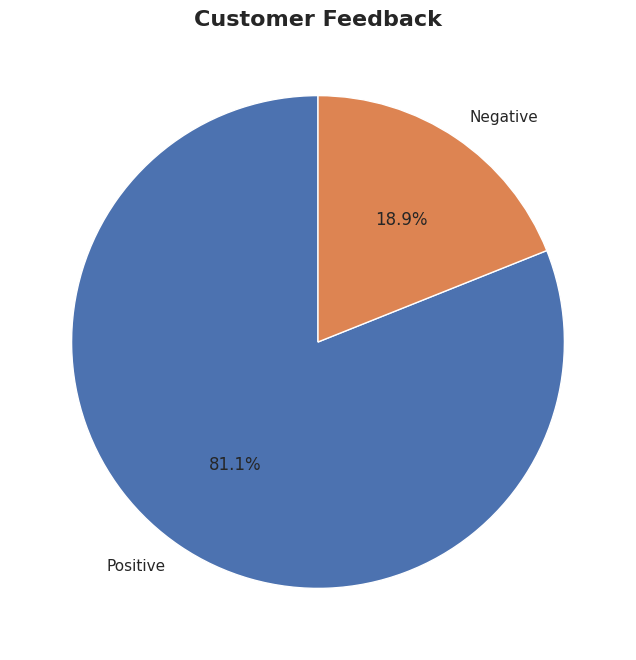

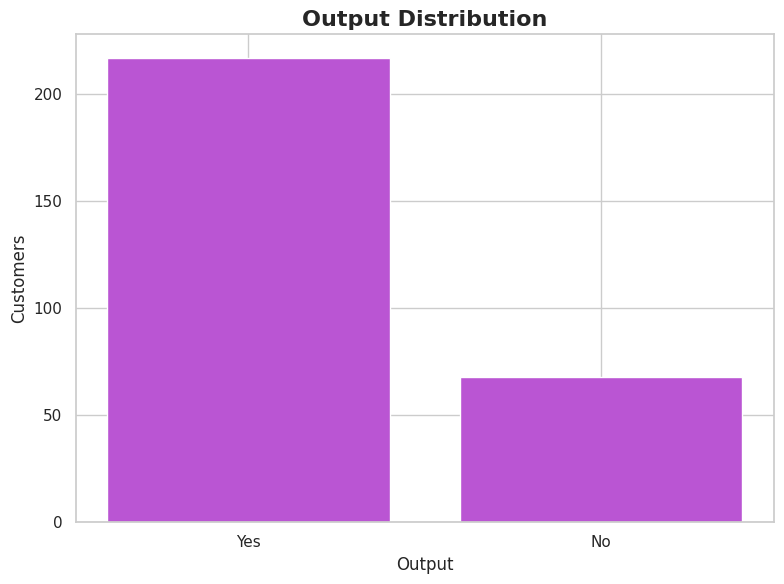

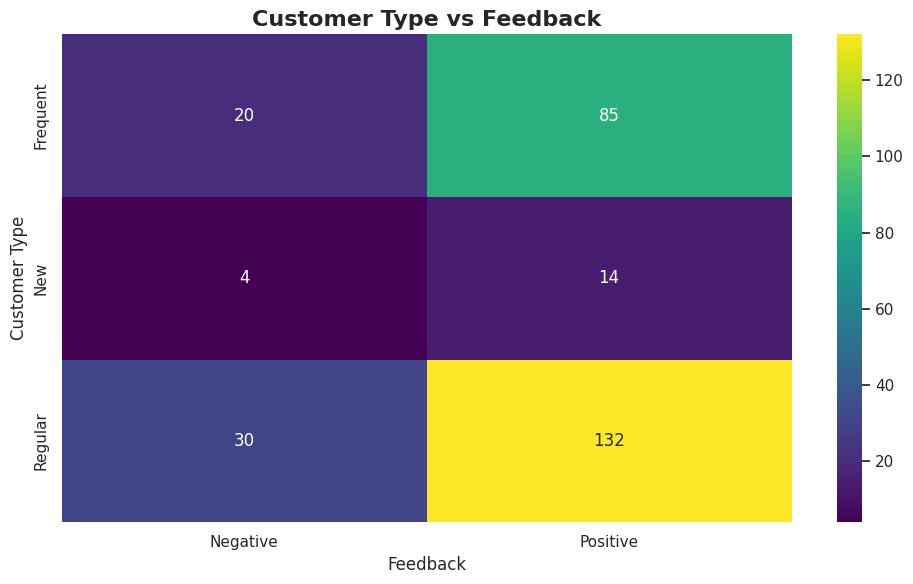

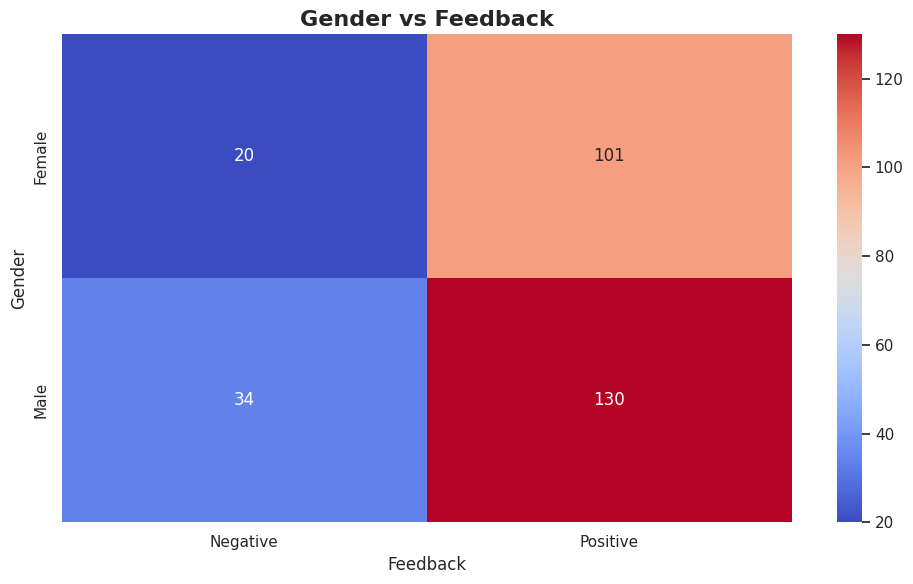

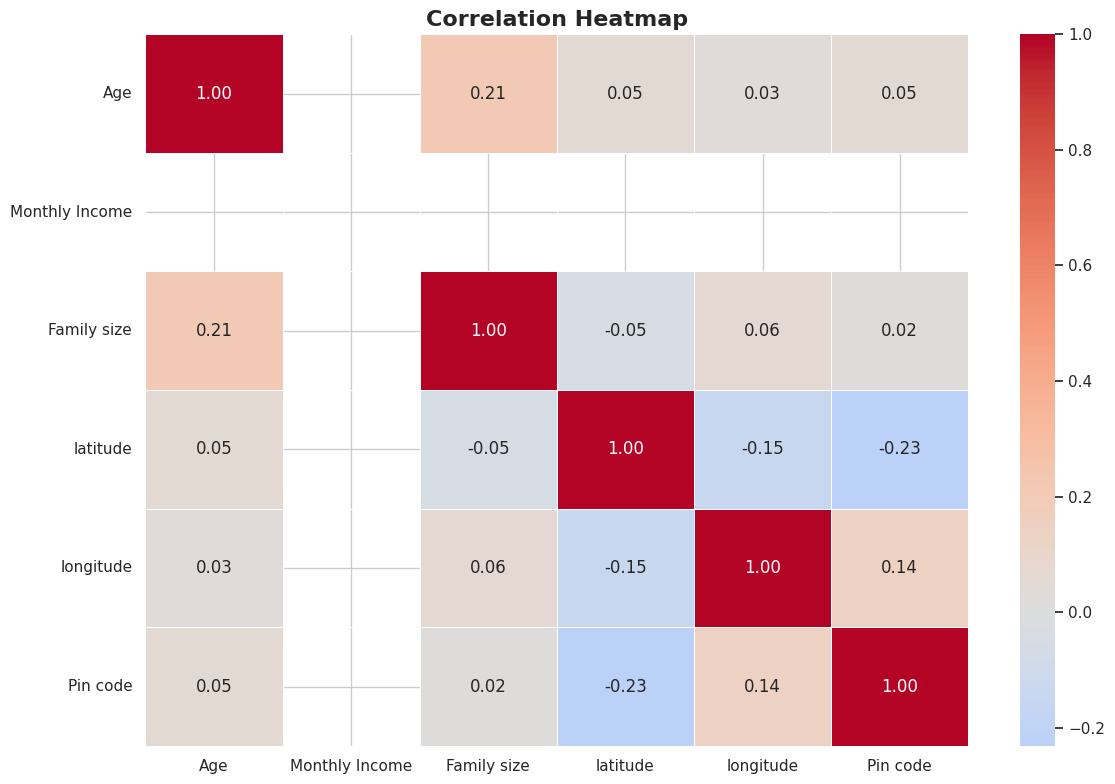

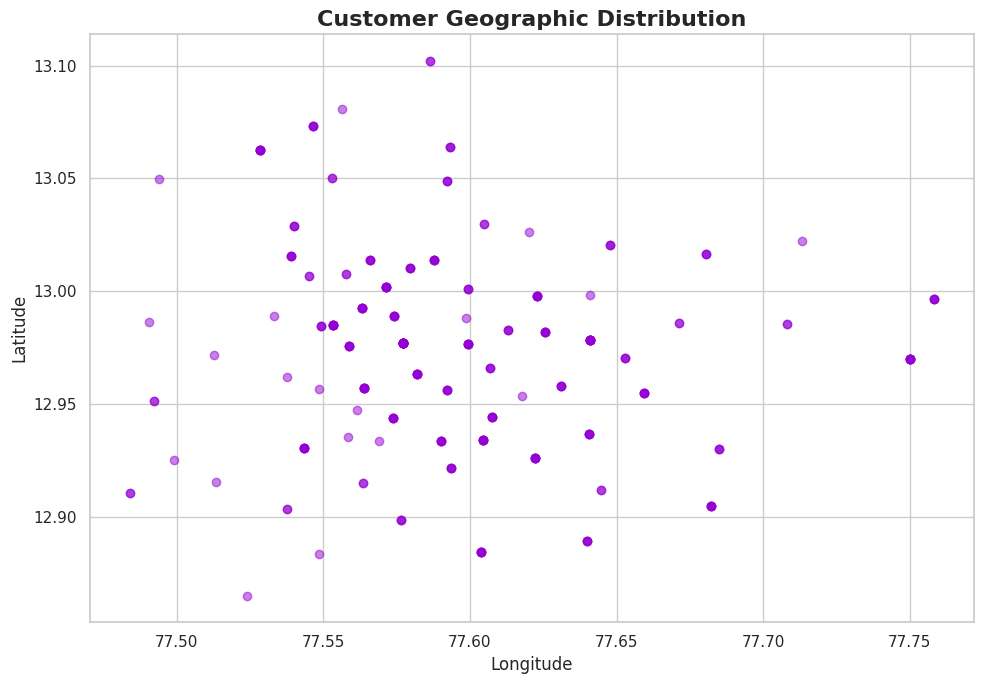

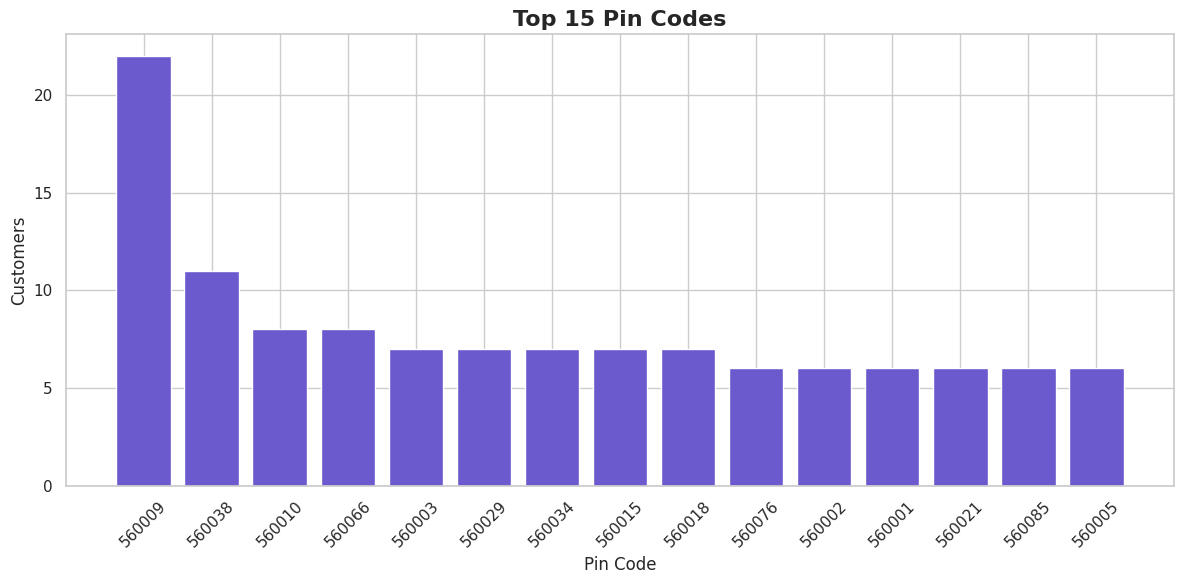


Age Outliers: 21

FINAL DATASET SUMMARY
Rows: 285
Columns: 13

Numeric columns:
['Age', 'Monthly Income', 'Family size', 'latitude', 'longitude', 'Pin code']

Categorical columns:
['Gender', 'Marital Status', 'Occupation', 'Educational Qualifications', 'Customer Type', 'Output', 'Feedback']

Final missing values:
Age                             0
Gender                          0
Marital Status                  0
Occupation                      0
Monthly Income                285
Educational Qualifications      0
Family size                     0
Customer Type                   0
latitude                        0
longitude                       0
Pin code                        0
Output                          0
Feedback                        0
dtype: int64

Dataset is ready for Machine Learning.

Clean dataset saved as: clean_customer_dataset.csv

DONE!


In [14]:
df.columns = df.columns.astype(str).str.strip()

# Remove unwanted unnamed columns
unnamed_cols = [col for col in df.columns if col.lower().startswith("unnamed")]

if len(unnamed_cols) > 0:
    df.drop(columns=unnamed_cols, inplace=True)

print("\nAfter removing unwanted columns:")
print(df.columns.tolist())

# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("\nDuplicate rows removed:", before - after)

# ============================================================
# 4. DEFINE COLUMNS
# ============================================================

numeric_columns = [
    "Age",
    "Monthly Income",
    "Family size",
    "latitude",
    "longitude",
    "Pin code"
]

categorical_columns = [
    "Gender",
    "Marital Status",
    "Occupation",
    "Educational Qualifications",
    "Customer Type",
    "Output",
    "Feedback"
]

# Keep only columns that actually exist
numeric_columns = [
    col for col in numeric_columns
    if col in df.columns
]

categorical_columns = [
    col for col in categorical_columns
    if col in df.columns
]

# ============================================================
# 5. CLEAN NUMERIC COLUMNS
# ============================================================

for col in numeric_columns:

    # Convert everything to string first
    df[col] = df[col].astype(str)

    # Remove commas
    df[col] = df[col].str.replace(",", "", regex=False)

    # Remove currency symbols
    df[col] = df[col].str.replace("₹", "", regex=False)
    df[col] = df[col].str.replace("$", "", regex=False)

    # Remove extra spaces
    df[col] = df[col].str.strip()

    # Convert to numeric
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# ============================================================
# 6. CLEAN CATEGORICAL COLUMNS
# ============================================================

for col in categorical_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )

    # Replace fake missing values
    df[col] = df[col].replace(
        [
            "",
            "nan",
            "NaN",
            "none",
            "None",
            "NULL",
            "null",
            "N/A",
            "NA",
            "-"
        ],
        np.nan
    )

# ============================================================
# 7. REPLACE INFINITY
# ============================================================

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# ============================================================
# 8. HANDLE MISSING NUMERIC VALUES
# ============================================================

for col in numeric_columns:

    if df[col].isna().all():

        print(
            f"WARNING: {col} contains no valid numeric values."
        )

    else:

        median_value = df[col].median()

        df[col] = df[col].fillna(median_value)

# ============================================================
# 9. HANDLE MISSING CATEGORICAL VALUES
# ============================================================

for col in categorical_columns:

    if df[col].isna().all():

        df[col] = df[col].fillna("Unknown")

    else:

        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value.iloc[0])
        else:
            df[col] = df[col].fillna("Unknown")

# ============================================================
# 10. DISPLAY CLEAN DATA
# ============================================================

print("\n" + "=" * 70)
print("CLEAN DATASET INFORMATION")
print("=" * 70)

print(df.info())

print("\nFirst 10 rows:")
print(df.head(10))

print("\nMissing values:")
print(df.isnull().sum())

# ============================================================
# 11. VISUALIZATION SETTINGS
# ============================================================

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

# ============================================================
# 12. AGE DISTRIBUTION
# ============================================================

if "Age" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Age",
        bins=20,
        kde=True,
        color="royalblue"
    )

    plt.title(
        "Age Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

# ============================================================
# 13. AGE BOXPLOT
# ============================================================

if "Age" in df.columns:

    age_data = pd.to_numeric(
        df["Age"],
        errors="coerce"
    ).dropna()

    if len(age_data) > 0:

        plt.figure(figsize=(10, 4))

        plt.boxplot(
            age_data,
            vert=False,
            patch_artist=True
        )

        plt.title(
            "Age Boxplot",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel("Age")

        plt.tight_layout()
        plt.show()

# ============================================================
# 14. GENDER DISTRIBUTION
# ============================================================

if "Gender" in df.columns:

    gender_counts = df["Gender"].value_counts()

    plt.figure(figsize=(8, 6))

    plt.bar(
        gender_counts.index.astype(str),
        gender_counts.values,
        color="purple"
    )

    plt.title(
        "Gender Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Gender")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

# ============================================================
# 15. GENDER PIE CHART
# ============================================================

if "Gender" in df.columns:

    gender_counts = df["Gender"].value_counts()

    plt.figure(figsize=(8, 8))

    plt.pie(
        gender_counts.values,
        labels=gender_counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(
        "Gender Percentage",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

# ============================================================
# 16. MARITAL STATUS
# ============================================================

if "Marital Status" in df.columns:

    counts = df["Marital Status"].value_counts()

    plt.figure(figsize=(10, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color="green"
    )

    plt.title(
        "Marital Status Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Marital Status")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

# ============================================================
# 17. OCCUPATION
# ============================================================

if "Occupation" in df.columns:

    counts = df["Occupation"].value_counts()

    plt.figure(figsize=(10, 7))

    plt.barh(
        counts.index.astype(str),
        counts.values,
        color="orange"
    )

    plt.title(
        "Occupation Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customers")
    plt.ylabel("Occupation")

    plt.tight_layout()
    plt.show()

# ============================================================
# 18. MONTHLY INCOME - SAFE CLEANING
# ============================================================

if "Monthly Income" in df.columns:

    income = pd.to_numeric(
        df["Monthly Income"],
        errors="coerce"
    )

    income = income.replace(
        [np.inf, -np.inf],
        np.nan
    )

    income = income.dropna()

    income = income[
        np.isfinite(income)
    ]

    print("\nMonthly Income Statistics:")
    print(income.describe())

    # --------------------------------------------------------
    # Histogram
    # --------------------------------------------------------

    if len(income) > 0:

        plt.figure(figsize=(10, 6))

        plt.hist(
            income.values,
            bins=20,
            color="teal",
            edgecolor="black"
        )

        plt.title(
            "Monthly Income Distribution",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel("Monthly Income")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # SAFE BOXPLOT
    # --------------------------------------------------------

    if len(income) > 0:

        plt.figure(figsize=(10, 4))

        plt.boxplot(
            income.to_numpy(),
            vert=False,
            patch_artist=True
        )

        plt.title(
            "Monthly Income Boxplot",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel("Monthly Income")

        plt.tight_layout()
        plt.show()

# ============================================================
# 19. EDUCATIONAL QUALIFICATIONS
# ============================================================

if "Educational Qualifications" in df.columns:

    counts = df[
        "Educational Qualifications"
    ].value_counts()

    plt.figure(figsize=(10, 7))

    plt.barh(
        counts.index.astype(str),
        counts.values,
        color="crimson"
    )

    plt.title(
        "Educational Qualifications",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customers")
    plt.ylabel("Education")

    plt.tight_layout()
    plt.show()

# ============================================================
# 20. FAMILY SIZE
# ============================================================

if "Family size" in df.columns:

    counts = df["Family size"].value_counts().sort_index()

    plt.figure(figsize=(10, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color="darkcyan"
    )

    plt.title(
        "Family Size Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Family Size")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()

# ============================================================
# 21. CUSTOMER TYPE
# ============================================================

if "Customer Type" in df.columns:

    counts = df["Customer Type"].value_counts()

    plt.figure(figsize=(10, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color="darkorange"
    )

    plt.title(
        "Customer Type Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Type")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

# ============================================================
# 22. FEEDBACK
# ============================================================

if "Feedback" in df.columns:

    counts = df["Feedback"].value_counts()

    plt.figure(figsize=(8, 8))

    plt.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(
        "Customer Feedback",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

# ============================================================
# 23. OUTPUT
# ============================================================

if "Output" in df.columns:

    counts = df["Output"].value_counts()

    plt.figure(figsize=(8, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color="mediumorchid"
    )

    plt.title(
        "Output Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Output")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()

# ============================================================
# 24. AGE VS MONTHLY INCOME
# ============================================================

if (
    "Age" in df.columns
    and
    "Monthly Income" in df.columns
):

    temp = df[
        ["Age", "Monthly Income"]
    ].copy()

    temp["Age"] = pd.to_numeric(
        temp["Age"],
        errors="coerce"
    )

    temp["Monthly Income"] = pd.to_numeric(
        temp["Monthly Income"],
        errors="coerce"
    )

    temp = temp.dropna()

    if len(temp) > 0:

        plt.figure(figsize=(10, 6))

        plt.scatter(
            temp["Age"],
            temp["Monthly Income"],
            alpha=0.6,
            color="blue"
        )

        plt.title(
            "Age vs Monthly Income",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel("Age")
        plt.ylabel("Monthly Income")

        plt.tight_layout()
        plt.show()

# ============================================================
# 25. FAMILY SIZE VS INCOME
# ============================================================

if (
    "Family size" in df.columns
    and
    "Monthly Income" in df.columns
):

    temp = df[
        ["Family size", "Monthly Income"]
    ].copy()

    temp["Family size"] = pd.to_numeric(
        temp["Family size"],
        errors="coerce"
    )

    temp["Monthly Income"] = pd.to_numeric(
        temp["Monthly Income"],
        errors="coerce"
    )

    temp = temp.dropna()

    if len(temp) > 0:

        plt.figure(figsize=(10, 6))

        sns.scatterplot(
            data=temp,
            x="Family size",
            y="Monthly Income",
            color="red"
        )

        plt.title(
            "Family Size vs Monthly Income",
            fontsize=16,
            fontweight="bold"
        )

        plt.tight_layout()
        plt.show()

# ============================================================
# 26. GENDER VS MONTHLY INCOME
# ============================================================

if (
    "Gender" in df.columns
    and
    "Monthly Income" in df.columns
):

    temp = df[
        ["Gender", "Monthly Income"]
    ].copy()

    temp["Monthly Income"] = pd.to_numeric(
        temp["Monthly Income"],
        errors="coerce"
    )

    temp = temp.dropna()

    if len(temp) > 0:

        plt.figure(figsize=(10, 6))

        sns.boxplot(
            data=temp,
            x="Gender",
            y="Monthly Income"
        )

        plt.title(
            "Gender vs Monthly Income",
            fontsize=16,
            fontweight="bold"
        )

        plt.xticks(rotation=30)

        plt.tight_layout()
        plt.show()

# ============================================================
# 27. CUSTOMER TYPE VS FEEDBACK
# ============================================================

if (
    "Customer Type" in df.columns
    and
    "Feedback" in df.columns
):

    cross_table = pd.crosstab(
        df["Customer Type"],
        df["Feedback"]
    )

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        cross_table,
        annot=True,
        fmt="d",
        cmap="viridis"
    )

    plt.title(
        "Customer Type vs Feedback",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Feedback")
    plt.ylabel("Customer Type")

    plt.tight_layout()
    plt.show()

# ============================================================
# 28. GENDER VS FEEDBACK
# ============================================================

if (
    "Gender" in df.columns
    and
    "Feedback" in df.columns
):

    cross_table = pd.crosstab(
        df["Gender"],
        df["Feedback"]
    )

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        cross_table,
        annot=True,
        fmt="d",
        cmap="coolwarm"
    )

    plt.title(
        "Gender vs Feedback",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Feedback")
    plt.ylabel("Gender")

    plt.tight_layout()
    plt.show()

# ============================================================
# 29. CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

if numeric_df.shape[1] >= 2:

    correlation = numeric_df.corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title(
        "Correlation Heatmap",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 30. PAIRPLOT
# ============================================================

pair_columns = [
    col for col in [
        "Age",
        "Monthly Income",
        "Family size"
    ]
    if col in df.columns
]

if len(pair_columns) >= 2:

    pair_data = df[pair_columns].copy()

    pair_data = pair_data.apply(
        pd.to_numeric,
        errors="coerce"
    )

    pair_data = pair_data.dropna()

    # Limit rows for faster plotting
    if len(pair_data) > 1000:
        pair_data = pair_data.sample(
            1000,
            random_state=42
        )

    if len(pair_data) > 1:

        sns.pairplot(
            pair_data
        )

        plt.show()

# ============================================================
# 31. LATITUDE VS LONGITUDE
# ============================================================

if (
    "latitude" in df.columns
    and
    "longitude" in df.columns
):

    geo = df[
        ["latitude", "longitude"]
    ].copy()

    geo["latitude"] = pd.to_numeric(
        geo["latitude"],
        errors="coerce"
    )

    geo["longitude"] = pd.to_numeric(
        geo["longitude"],
        errors="coerce"
    )

    geo = geo.dropna()

    if len(geo) > 0:

        plt.figure(figsize=(10, 7))

        plt.scatter(
            geo["longitude"],
            geo["latitude"],
            alpha=0.5,
            color="darkviolet"
        )

        plt.title(
            "Customer Geographic Distribution",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        plt.tight_layout()
        plt.show()

# ============================================================
# 32. PIN CODE DISTRIBUTION
# ============================================================

if "Pin code" in df.columns:

    pin = pd.to_numeric(
        df["Pin code"],
        errors="coerce"
    ).dropna()

    counts = pin.value_counts().head(15)

    if len(counts) > 0:

        plt.figure(figsize=(12, 6))

        plt.bar(
            counts.index.astype(str),
            counts.values,
            color="slateblue"
        )

        plt.title(
            "Top 15 Pin Codes",
            fontsize=16,
            fontweight="bold"
        )

        plt.xlabel("Pin Code")
        plt.ylabel("Customers")

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

# ============================================================
# 33. AGE OUTLIERS
# ============================================================

if "Age" in df.columns:

    age = pd.to_numeric(
        df["Age"],
        errors="coerce"
    ).dropna()

    if len(age) > 0:

        Q1 = age.quantile(0.25)
        Q3 = age.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        age_outliers = age[
            (age < lower) |
            (age > upper)
        ]

        print("\nAge Outliers:", len(age_outliers))

# ============================================================
# 34. MONTHLY INCOME OUTLIERS
# ============================================================

if "Monthly Income" in df.columns:

    income = pd.to_numeric(
        df["Monthly Income"],
        errors="coerce"
    ).dropna()

    if len(income) > 0:

        Q1 = income.quantile(0.25)
        Q3 = income.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        income_outliers = income[
            (income < lower) |
            (income > upper)
        ]

        print(
            "Monthly Income Outliers:",
            len(income_outliers)
        )

# ============================================================
# 35. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nNumeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nFinal missing values:")
print(df.isnull().sum())

print("\nDataset is ready for Machine Learning.")

# ============================================================
# 36. SAVE CLEAN DATASET
# ============================================================

df.to_csv(
    "clean_customer_dataset.csv",
    index=False
)

print(
    "\nClean dataset saved as: "
    "clean_customer_dataset.csv"
)

print("\nDONE!")

## Thank you..pls upvote!!!!!!!!